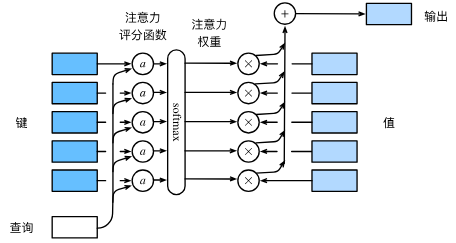

In [1]:
import sys
sys.path.append('../src')
from llm_util import *

import math
import torch
from torch import nn

masked_softmax函数 实现了这样的掩蔽softmax操作（masked softmax operation）， 其中任何超出有效长度的位置都被掩蔽并置为0。

In [14]:
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        print(shape)
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
            print(valid_lens)
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        print(X.reshape(-1, shape[-1]))
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                              value=-1e6)
        print(X)
        print(X.reshape(shape))
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [15]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

torch.Size([2, 2, 4])
tensor([2, 2, 3, 3])
tensor([[0.4758, 0.8953, 0.3873, 0.5768],
        [0.2968, 0.5025, 0.1685, 0.6272],
        [0.8170, 0.3053, 0.3793, 0.4946],
        [0.5858, 0.0284, 0.8845, 0.3323]])
tensor([[ 4.7581e-01,  8.9532e-01, -1.0000e+06, -1.0000e+06],
        [ 2.9681e-01,  5.0246e-01, -1.0000e+06, -1.0000e+06],
        [ 8.1704e-01,  3.0527e-01,  3.7929e-01, -1.0000e+06],
        [ 5.8584e-01,  2.8362e-02,  8.8447e-01, -1.0000e+06]])
tensor([[[ 4.7581e-01,  8.9532e-01, -1.0000e+06, -1.0000e+06],
         [ 2.9681e-01,  5.0246e-01, -1.0000e+06, -1.0000e+06]],

        [[ 8.1704e-01,  3.0527e-01,  3.7929e-01, -1.0000e+06],
         [ 5.8584e-01,  2.8362e-02,  8.8447e-01, -1.0000e+06]]])


tensor([[[0.3966, 0.6034, 0.0000, 0.0000],
         [0.4488, 0.5512, 0.0000, 0.0000]],

        [[0.4455, 0.2670, 0.2875, 0.0000],
         [0.3424, 0.1961, 0.4615, 0.0000]]])

In [16]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

torch.Size([2, 2, 4])
tensor([[0.9497, 0.1486, 0.9283, 0.5375],
        [0.5697, 0.2823, 0.7944, 0.9810],
        [0.1605, 0.8727, 0.5644, 0.2832],
        [0.0538, 0.1833, 0.0923, 0.0872]])
tensor([[ 9.4970e-01, -1.0000e+06, -1.0000e+06, -1.0000e+06],
        [ 5.6971e-01,  2.8228e-01,  7.9438e-01, -1.0000e+06],
        [ 1.6045e-01,  8.7274e-01, -1.0000e+06, -1.0000e+06],
        [ 5.3823e-02,  1.8333e-01,  9.2302e-02,  8.7249e-02]])
tensor([[[ 9.4970e-01, -1.0000e+06, -1.0000e+06, -1.0000e+06],
         [ 5.6971e-01,  2.8228e-01,  7.9438e-01, -1.0000e+06]],

        [[ 1.6045e-01,  8.7274e-01, -1.0000e+06, -1.0000e+06],
         [ 5.3823e-02,  1.8333e-01,  9.2302e-02,  8.7249e-02]]])


tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3331, 0.2499, 0.4170, 0.0000]],

        [[0.3291, 0.6709, 0.0000, 0.0000],
         [0.2374, 0.2703, 0.2468, 0.2455]]])

In [18]:
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size，“键－值”对的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [19]:
torch.set_printoptions(threshold=float('inf'))

In [20]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(
    2, 1, 1)
valid_lens = torch.tensor([2, 6])

In [21]:
queries

tensor([[[-0.1628,  0.8913,  0.2831,  0.0612, -1.0431,  1.2788, -1.2000,
          -1.3371,  0.5845, -0.3035,  0.0330, -0.8090, -0.3184,  0.4475,
          -0.5365,  0.9288,  1.1651,  0.9854,  0.0485, -0.3852]],

        [[-0.0439, -0.1308,  0.2516, -0.0826, -1.4989,  0.6830,  1.5100,
           0.4210, -0.4944,  0.0815, -0.5655, -2.0080, -0.6228,  0.3969,
           0.1129, -0.0940,  0.5822,  0.3145, -1.6708,  0.3434]]])

In [22]:
keys

tensor([[[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]]])

In [23]:
values

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.],
         [24., 25., 26., 27.],
         [28., 29., 30., 31.],
         [32., 33., 34., 35.],
         [36., 37., 38., 39.]],

        [[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.],
         [24., 25., 26., 27.],
         [28., 29., 30., 31.],
         [32., 33., 34., 35.],
         [36., 37., 38., 39.]]])

In [24]:
torch.arange(40, dtype=torch.float32).reshape(1, 10, 4)

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.],
         [24., 25., 26., 27.],
         [28., 29., 30., 31.],
         [32., 33., 34., 35.],
         [36., 37., 38., 39.]]])

In [25]:
attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                              dropout=0.1)

In [26]:
attention.eval()

AdditiveAttention(
  (W_k): Linear(in_features=2, out_features=8, bias=False)
  (W_q): Linear(in_features=20, out_features=8, bias=False)
  (w_v): Linear(in_features=8, out_features=1, bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [27]:
for name, param in attention.named_parameters():
    print(f"--- {name} ---")
    print(param)

--- W_k.weight ---
Parameter containing:
tensor([[ 0.6584,  0.0239],
        [ 0.1670,  0.2171],
        [-0.3958, -0.3113],
        [-0.1974, -0.3048],
        [-0.2895,  0.2085],
        [-0.6883, -0.5725],
        [ 0.3175,  0.1483],
        [-0.6656, -0.3493]], requires_grad=True)
--- W_q.weight ---
Parameter containing:
tensor([[ 0.1707, -0.0673,  0.0849,  0.0241,  0.1947,  0.0036, -0.1509, -0.0896,
         -0.1788, -0.1922,  0.0650, -0.1701, -0.1395, -0.0630, -0.2169,  0.1486,
          0.1167,  0.2213,  0.2221, -0.0736],
        [-0.1314, -0.1647, -0.1088, -0.0188, -0.1885,  0.0378,  0.2091,  0.0443,
          0.0976,  0.0832,  0.1171,  0.1888, -0.1211, -0.0021,  0.2071, -0.1902,
         -0.0367, -0.1519, -0.0234, -0.0569],
        [ 0.1745,  0.0350,  0.0619, -0.1548,  0.0942, -0.0338,  0.0090, -0.0858,
         -0.1002, -0.1426,  0.0723,  0.2174,  0.0481,  0.0557,  0.0128, -0.1359,
          0.0145,  0.1529, -0.1496,  0.1212],
        [ 0.1792, -0.0093, -0.0291,  0.2158, -0.0

In [28]:
attention(queries, keys, values, valid_lens)

torch.Size([2, 1, 10])
tensor([2, 6])
tensor([[-0.0619, -0.0619, -0.0619, -0.0619, -0.0619, -0.0619, -0.0619, -0.0619,
         -0.0619, -0.0619],
        [-0.2718, -0.2718, -0.2718, -0.2718, -0.2718, -0.2718, -0.2718, -0.2718,
         -0.2718, -0.2718]], grad_fn=<ViewBackward0>)
tensor([[-6.1921e-02, -6.1921e-02, -1.0000e+06, -1.0000e+06, -1.0000e+06,
         -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06],
        [-2.7184e-01, -2.7184e-01, -2.7184e-01, -2.7184e-01, -2.7184e-01,
         -2.7184e-01, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06]],
       grad_fn=<AsStridedBackward0>)
tensor([[[-6.1921e-02, -6.1921e-02, -1.0000e+06, -1.0000e+06, -1.0000e+06,
          -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06]],

        [[-2.7184e-01, -2.7184e-01, -2.7184e-01, -2.7184e-01, -2.7184e-01,
          -2.7184e-01, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06]]],
       grad_fn=<ViewBackward0>)


tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

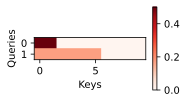

In [29]:
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

In [30]:
attention.attention_weights

tensor([[[0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000,
          0.0000, 0.0000]]], grad_fn=<SoftmaxBackward0>)

In [58]:
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries的形状：(batch_size，查询的个数，d)
    # keys的形状：(batch_size，“键－值”对的个数，d)
    # values的形状：(batch_size，“键－值”对的个数，值的维度)
    # valid_lens的形状:(batch_size，)或者(batch_size，查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b=True为了交换keys的最后两个维度
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        print(scores)
        self.attention_weights = masked_softmax(scores, valid_lens)
        print("attention_weights:")
        print(self.attention_weights)
        print("values:")
        print(values)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [59]:
queries = torch.normal(0, 1, (2, 1, 2))

In [60]:
attention = DotProductAttention(dropout=0.5)

In [61]:
attention.eval()

DotProductAttention(
  (dropout): Dropout(p=0.5, inplace=False)
)

In [62]:
attention(queries, keys, values, valid_lens)

tensor([[[-1.8756, -1.8756, -1.8756, -1.8756, -1.8756, -1.8756, -1.8756,
          -1.8756, -1.8756, -1.8756]],

        [[-0.3683, -0.3683, -0.3683, -0.3683, -0.3683, -0.3683, -0.3683,
          -0.3683, -0.3683, -0.3683]]])
torch.Size([2, 1, 10])
tensor([2, 6])
tensor([[-1.8756, -1.8756, -1.8756, -1.8756, -1.8756, -1.8756, -1.8756, -1.8756,
         -1.8756, -1.8756],
        [-0.3683, -0.3683, -0.3683, -0.3683, -0.3683, -0.3683, -0.3683, -0.3683,
         -0.3683, -0.3683]])
tensor([[-1.8756e+00, -1.8756e+00, -1.0000e+06, -1.0000e+06, -1.0000e+06,
         -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06],
        [-3.6833e-01, -3.6833e-01, -3.6833e-01, -3.6833e-01, -3.6833e-01,
         -3.6833e-01, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06]])
tensor([[[-1.8756e+00, -1.8756e+00, -1.0000e+06, -1.0000e+06, -1.0000e+06,
          -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06, -1.0000e+06]],

        [[-3.6833e-01, -3.6833e-01, -3.6833e-01, -3.6833e-01, -3.

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])